**BEUST Léna**

________________

# **Name Classification**

In [ ]:
import glob
import os
import string

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.ticker as ticker

from sklearn.metrics import confusion_matrix

### Load Data

The names can be found in text files in a src directory, one file per language.

In the following you can find some utilities to load the data into pandas data frames. 

We will restrict to some common European languages. 

With the given selection, we will identify all the occurring characters and initialize an alphabet.<br>
For this alphabet, we will use a one-hot-encoding to map them into a vector space representation. 

Foresee a suitable character for the end of the word, e.g. 'END'.

In [ ]:
srcdir = 'data/names'
languages = ["English","French","Italian","German","Spanish"]

In [ ]:
# inspect the data directory
def findFiles(path): 
    return glob.glob(path)

In [ ]:
print('\n'.join(findFiles(os.path.join(srcdir,'*.txt'))))

data/names/Chinese.txt
data/names/Portuguese.txt
data/names/Vietnamese.txt
data/names/Russian.txt
data/names/Italian.txt
data/names/Japanese.txt
data/names/German.txt
data/names/Arabic.txt
data/names/Spanish.txt
data/names/Korean.txt
data/names/English.txt
data/names/French.txt
data/names/Irish.txt
data/names/Scottish.txt
data/names/Dutch.txt
data/names/Greek.txt
data/names/Polish.txt
data/names/Czech.txt


In [ ]:
# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return lines

def load_data(srcdir, categories=None):
    names_list = []
    for filename in findFiles(os.path.join(srcdir,'*.txt')):
        category = os.path.splitext(os.path.basename(filename))[0]
        if not categories or category in categories: 
            names = readLines(filename)
            names_list.extend([(name,category) for name in names])
    df = pd.DataFrame(names_list)
    df.columns = ["name","lang"]
    return df

In [ ]:
names = load_data(srcdir,categories=languages)
names.head()

,name,lang
0,Abandonato,Italian
1,Abatangelo,Italian
2,Abatantuono,Italian
3,Abate,Italian
4,Abategiovanni,Italian


In [ ]:
maxlen = np.max([len(name) for name in names.name])
print("Maximum name length: ", maxlen)

Maximum name length:  18


In [ ]:
alphabet = sorted(list(set(''.join([name for name in names.name]))))
alphabet.append('END')
len_alphabet = len(alphabet)
char_index = dict((c, i) for i, c in enumerate(alphabet))
print("Size of alphabet: ",len_alphabet)
print(alphabet)

Size of alphabet:  74
[' ', "'", 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'Á', 'É', 'ß', 'à', 'á', 'ä', 'ç', 'è', 'é', 'ê', 'ì', 'í', 'ñ', 'ò', 'ó', 'ö', 'ù', 'ú', 'ü', 'END']


In [ ]:
names.groupby('lang')['name'].count()/len(names)

lang
English    0.646230
French     0.048802
German     0.127555
Italian    0.124912
Spanish    0.052502
Name: name, dtype: float64

### Vector Representations

Now construct the vector representation by using one-hot-vectors. 

In [ ]:
language_to_index = {country:index for index,country in enumerate(names.lang.unique())}
index_to_language = {index:country for index,country in enumerate(names.lang.unique())}

def onehot(i, length):
    v = np.zeros(length);
    v[i] = 1
    return v

def name_representation(name, maxlen):
    ### START YOUR CODE
    name_trunc = str(name)[0:maxlen]
    size = len(char_index)
    vector = [onehot(char_index[j], size) for j in str(name)]
    # fill the rest with 
    for k in range(0,maxlen - len(str(name))):
        vector.append(onehot(char_index['END'], size))
    return vector
    ### START YOUR CODE

def lang_representation(language, language_to_index):
    y = np.zeros(len(language_to_index))
    y[language_to_index[language]]=1
    return y

def lang_from_output(score):
    return index_to_language[np.argmax(score)]

def predict(name, model):
    score = model.predict(np.array([name_representation(name, maxlen)]))[0]
    return lang_from_output(score)

### Prepare train/test

Split the data into train/test

Shuffle the data

Transform the names data into a suitable vector respresentation:
* names into numpy arrays of shape (*,maxlen,len_alphabet)
* language into numpy array of shape (*,len(languages))



In [ ]:
test_split = 0.2

### START YOUR CODE
# Shuffle and split names data
names_shuffled = names.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(names_shuffled) * (1 - test_split))

train = names_shuffled.iloc[:split_idx]
# iloc: selection les données avec des index entiers numériques (pas nom de colonne)

test = names_shuffled.iloc[split_idx:]

### END YOUR CODE

In [ ]:
### START YOUR CODE

# Map train and test data into vector space (one-hot-vectors)

X_train = np.array([name_representation(name, maxlen) for name in train['name']])
Y_train = np.array([lang_representation(lang, language_to_index) for lang in train['lang']])

X_test  = np.array([name_representation(name, maxlen) for name in test['name']])
Y_test  = np.array([lang_representation(lang, language_to_index) for lang in test['lang']])


### END YOUR CODE

Possibly, pack the data into a Dataset (e.g. when working with in PyTorch)

### Define and Train Model: Single Layer with SimpleRNN

Create an RNN consisting of a single layer with a SimpleRNN (keras) and a softmax.

Then train the model. Play with different number of hidden units in the layer to obtain a good accuracy.

In [15]:
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf

### START YOUR CODE
batch_sizes = [32, 64, 128]
nepochs = 20

hidden_units_list = [64, 128, 256] # 6 models to tests with 3 numbers of hidden units and 3 batch sizes

results = {}
i = -1

for hidden_units, batch_size in itertools.product(hidden_units_list, batch_sizes):
    i += 1
    
    model = tf.keras.Sequential([
        tf.keras.layers.SimpleRNN(hidden_units, input_shape=(maxlen, len_alphabet)),
        tf.keras.layers.Dense(len(language_to_index), activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_test, Y_test),
        verbose=1
    )
    
    results[i] = {
        'model':         model,
        'hidden_units':  hidden_units,
        'batch_size':    batch_size,
        'val_acc':       history.history['val_accuracy'],
        'train_loss':    history.history['loss'],
        'val_loss':      history.history['val_loss'],
        'final_val_acc': history.history['val_accuracy'][-1],
    }
    
### END YOUR CODE

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6489 - loss: 1.0297 - val_accuracy: 0.7121 - val_loss: 0.8554
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7112 - loss: 0.8223 - val_accuracy: 0.7438 - val_loss: 0.7766
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7344 - loss: 0.7480 - val_accuracy: 0.7306 - val_loss: 0.8097
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7504 - loss: 0.7104 - val_accuracy: 0.7509 - val_loss: 0.7292
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7626 - loss: 0.6669 - val_accuracy: 0.7342 - val_loss: 0.7773
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7676 - loss: 0.6449 - val_accuracy: 0.7606 - val_loss: 0.7153
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7848 - loss: 0.6224 - val_accuracy: 0.7588 - val_loss: 0.6961
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7919 - loss: 0.5864 - val_accur

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


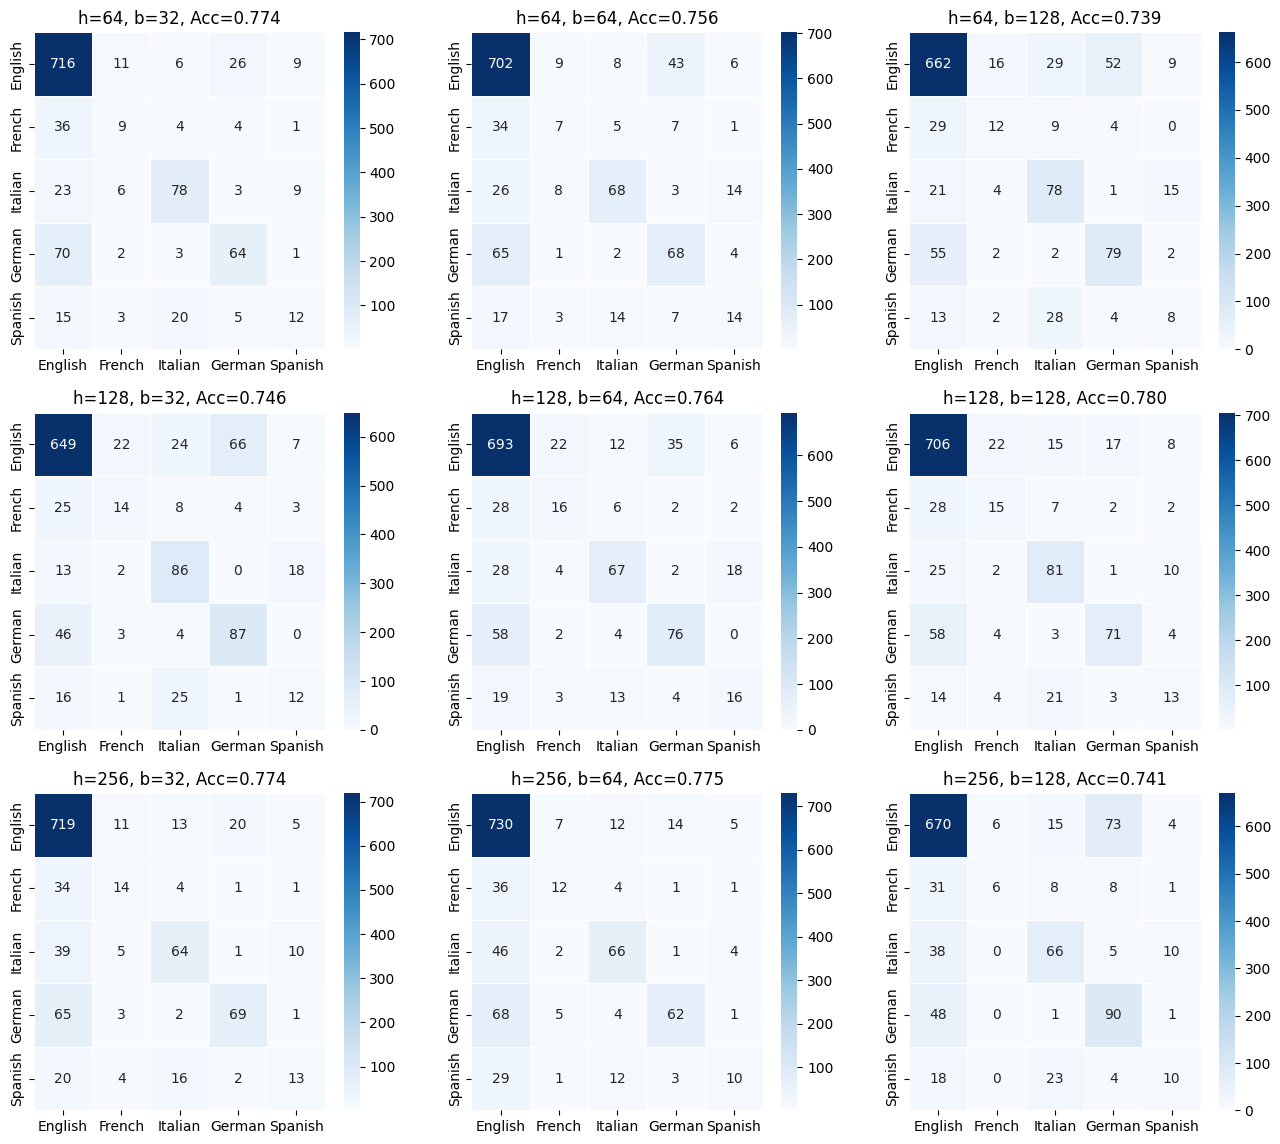

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

n_models = len(results)
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, res in results.items():
    m = res['model']
    h = res['hidden_units']
    b = res['batch_size']
    val_acc  = res['final_val_acc']

    Y_pred = np.argmax(m.predict(X_test), axis=1)   # axis x
    Y_true = np.argmax(Y_test,axis=1)   # axis y
    pred_langs = [index_to_language[j] for j in Y_pred]
    true_langs = [index_to_language[j] for j in Y_true]

    cm = confusion_matrix(true_langs, pred_langs, labels=languages)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=languages, yticklabels=languages,
                ax=axes[i], linewidths=0.5)
    axes[i].set_title(f"h={h}, b={b}, Acc={val_acc:.3f}")

plt.show()

#### Findings

If we analyze the accuracy of all model, the best number of hidden states seems to be **128**. Indeed, with **64** layers the model isn't able to learn; but with **256** the model become to costly. Regarding to our tests, it seems also that a batch size of **128** is a good value.

### Implement Model with several SimpleRNN Layers

In [24]:
### START YOUR CODE
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(128, input_shape=(maxlen, len_alphabet), return_sequences=True),
    tf.keras.layers.SimpleRNN(128, return_sequences=True),
    tf.keras.layers.SimpleRNN(128),
    tf.keras.layers.Dense(len(language_to_index), activation='softmax')
])
    
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train...
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=1
)

results = {
    'model':         model,
    'val_acc':       history.history['val_accuracy'],
    'train_loss':    history.history['loss'],
    'val_loss':      history.history['val_loss'],
    'final_val_acc': history.history['val_accuracy'][-1],
}

### END YOUR CODE

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6348 - loss: 1.1272 - val_accuracy: 0.6752 - val_loss: 0.9586
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7026 - loss: 0.8585 - val_accuracy: 0.7377 - val_loss: 0.7790
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7522 - loss: 0.7021 - val_accuracy: 0.7465 - val_loss: 0.7266
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7749 - loss: 0.6187 - val_accuracy: 0.7632 - val_loss: 0.6941
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8031 - loss: 0.5571 - val_accuracy: 0.7298 - val_loss: 0.7194
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8178 - loss: 0.5098 - val_accuracy: 0.7606 - val_loss: 0.6624
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8315 - loss: 0.4642 - val_accuracy: 0.7509 - val_loss: 0.6895
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8478 - loss: 0.4232 - val_accuracy: 0.7570 - v

We can see on the previous cell that we achieve **95%** of accuracy by stacking 3 SimpleRNN layers. We can improve the performance of the model thank to multiple RNN layers.

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


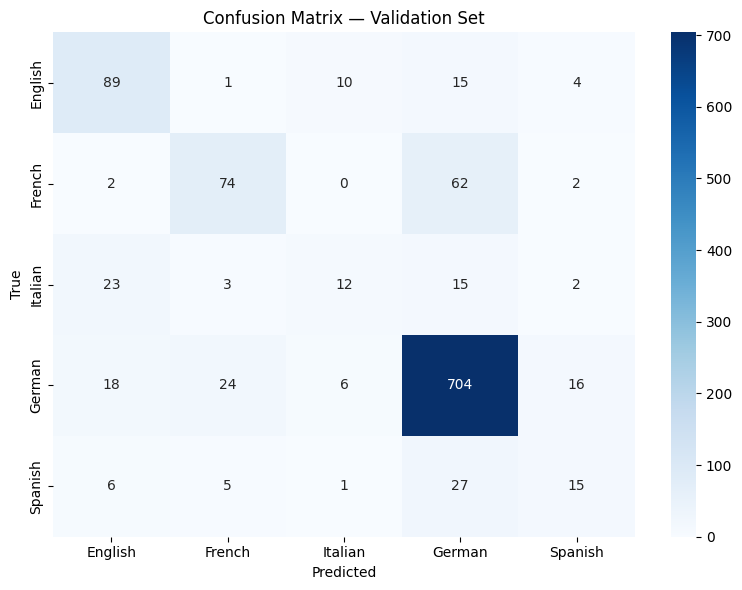

In [27]:
### START YOUR CODE
import seaborn as sns

m = results['model']
val_acc  = results['final_val_acc']
Y_pred = np.argmax(m.predict(X_test), axis=1)   # axis x
Y_true = np.argmax(Y_test,axis=1)   # axis y
cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=languages, yticklabels=languages)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.show()

### END YOUR CODE

#### Findings

We created a model that can detect very well German names by stacking 3 RNN layers.

### Class Imbalance Handling

Choose a method to address the class imbalance seen in the given example.
- minority resampling 
- class weights in the loss

Implement it and incorporate it in the training.
Evaluate the results and compare it with the results obtained with the unbalanced training.  

______________


Let's use the Synthetic Minority Oversampling Technique (SMOTE) : 

SMOTE is a data level technique used to handle imbalanced datasets by creating new synthetic samples for the minority class instead of duplicating existing ones. In SMOTE a minority class data point is first selected then its k-nearest neighbors are identified and finally a new synthetic data point is generated between the selected point and one of its neighbors.

In [4]:
!pip install imblearn

In [24]:
### START YOUR CODE

from imblearn.over_sampling import SMOTE

X_train_2d = X_train.reshape(X_train.shape[0], -1)  # Flatten to (4540, 18*74) for SMOTE
Y_train_1d = np.argmax(Y_train, axis=1)  # Converts one-hot to class indices for SMOTE

print("Class distribution before SMOTE:", len(Y_train_1d))
smote = SMOTE(sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_2d, Y_train_1d)
print("Class distribution after SMOTE:", len(y_train_resampled))

### END YOUR CODE

Class distribution before SMOTE: 4540
Class distribution after SMOTE: 14500


SMOTE successfully increased the number of samples from 4,540 to 14,500. SMOTE oversamples the minority classes to balance the class distribution, and the total number of samples after resampling depends on the sampling_strategy and the original class imbalance.

/!\ SMOTE creates synthetic samples based on the training data : only apply SMOTE to the training set, not the test set.

We can train the previous model (the one with 3 stacked rnn layers) with these new datas.

In [27]:
import tensorflow as tf
from keras.utils import to_categorical

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(128, input_shape=(maxlen, len_alphabet), return_sequences=True),
    tf.keras.layers.SimpleRNN(128, return_sequences=True),
    tf.keras.layers.SimpleRNN(128),
    tf.keras.layers.Dense(len(language_to_index), activation='softmax')
])
    
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

X_train_resampled_3d = X_train_resampled.reshape(-1, 18, 74) # reshape to be useable
y_train_resampled_onehot = to_categorical(y_train_resampled, num_classes=5)

history = model.fit(
    X_train_resampled_3d, y_train_resampled_onehot,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=1
)

results = {
    'model':         model,
    'val_acc':       history.history['val_accuracy'],
    'train_loss':    history.history['loss'],
    'val_loss':      history.history['val_loss'],
    'final_val_acc': history.history['val_accuracy'][-1],
}

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


2026-05-04 14:57:49.656650: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 77256000 exceeds 10% of free system memory.


114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6580 - loss: 0.8896 - val_accuracy: 0.5678 - val_loss: 1.0324
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8377 - loss: 0.4564 - val_accuracy: 0.6743 - val_loss: 0.8707
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8838 - loss: 0.3327 - val_accuracy: 0.7482 - val_loss: 0.7857
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9243 - loss: 0.2313 - val_accuracy: 0.7033 - val_loss: 0.8945
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9366 - loss: 0.1989 - val_accuracy: 0.7658 - val_loss: 0.7905
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9498 - loss: 0.1615 - val_accuracy: 0.7280 - val_loss: 0.8846
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9574 - loss: 0.1365 - val_accuracy: 0.7491 - val_loss: 0.9193
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9541 - loss: 0.1353 - val_accuracy: 0.739

We achieve an very good accuracy of **96.87%** by resampling the minority class and stacking SimpleRNN layers.